In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [5]:
import pandas as pd
import numpy as np
from numpy import errstate,isneginf
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sc

import zipfile 
import os         
import json
import requests
import io
import copy
import biomart 
import umap

In [6]:
# paths to directories containing the datasets

rnaseq_path = '/home/swapnanil_mukherjee/cancer_data/RNASeq_data/'  
mcarray_path = '/home/swapnanil_mukherjee/cancer_data/Microarray_data/' 
stemmappers_matrix_data = '/home/swapnanil_mukherjee/cancer_data/stemmappers_matrix_data/'
stemmappers_sample_data = '/home/swapnanil_mukherjee/cancer_data/stemmappers_data/'

In [7]:
def process_df(df, log=False):
     # converting the rows which are single bytestrings into str 
    for i in range(len(df.iloc[:, :])):
        df[0][i] = df[0][i].decode('utf-8')
                        
    # splitting each row which is one single string into different columns
    df = df[0].str.split('\t', expand = True)
    
    # removing the last row of the first column which has a NaN value 
    df[0] = df[0][:-1]
                        
    # removing the trailing '\n' from every row in the last column
    df.iloc[:,-1] = df.iloc[:, -1].apply(lambda x: x[:-1] if type(x)!='NoneType' else x)
    
    # replacing the zeroes in the table with ones so that log can be applied efficiently [not required to do]
    # df.replace(to_replace='0', value='1', inplace=True)

    # replacing whitespaces by 0
    df = df.replace(r'^\s*$', '0', regex=True)
    
    # removing the index column and making the ensemble ids the index, 
    # and making sample ids the column headers
    df = df.set_index(list(df)[0])
    header = df.iloc[0]
    df = df[1:]
    df.columns = header
    
    #applying computing cpm, applying log and computing z-score for each column of the dataframe
#     for i in df.columns:        
#         if log == True:
#             # computing cpm of each value
#             df[i] = (df[i].astype('float')/np.sum(df[i].astype('float')))*(10**6)
            
#             #adding 1 to each value before applying log
#             df[i] = df[i].astype('float')+1
            
#             #applying log
#             df[i] = np.log2(df[i])
        
#         # applying z-score function
#         df[i] = sc.zscore(df[i].astype('float'))

    return df


def get_df(path, i):
    
    if path == rnaseq_path:
        expression_type = 'expression_counts'
        do_log = True
    elif path == mcarray_path:
        expression_type = 'expression_genes'
        do_log = False
        
    # opens each zip file
    with zipfile.ZipFile(path + i) as f:
        print(i)
        # iterates through every file inside the zip file
        for file_name in f.namelist():
            # opens the expressions file
            if expression_type in file_name:
                with f.open(file_name, mode='r') as thefile:
                    df = pd.DataFrame(thefile)
                    df = process_df(df, log=do_log)
                    return df 


def get_list_of_dfs():   
    
    list_of_dfs = []
    
    for i in os.listdir(rnaseq_path):
        list_of_dfs.append(get_df(rnaseq_path, i))
    
    for i in os.listdir(mcarray_path):
        list_of_dfs.append(get_df(mcarray_path, i))
    
    return list_of_dfs                 

In [224]:
# with zipfile.ZipFile(rnaseq_path+'7284.zip') as f:
#         # iterates through every file inside the zip file
#         for file_name in f.namelist():
#             # opens the expressions file
#             if 'expression_counts' in file_name:
#                 with f.open(file_name, mode='r') as thefile:
#                     df = pd.DataFrame(thefile)

# for i in range(len(df.iloc[:, :])):
#     df[0][i] = df[0][i].decode('utf-8')

# df = df[0].str.split('\t', expand = True)
# df[0] = df[0][:-1]
# df.head(6)

In [225]:
# df.iloc[:,-1] = df.iloc[:, -1].apply(lambda x: x[:-1])
# # df.replace(to_replace='0', value='1', inplace=True)
# df = df.replace(r'^\s*$', '0', regex=True)
# df.head(6)

In [226]:
# df = df.set_index(list(df)[0])
# header = df.iloc[0]
# df = df[1:]
# df.columns = header
# df.head(6)

In [227]:
# for i in df.columns:
#     df[i] = (df[i].astype('float')/np.sum(df[i].astype('float')))*(10**6)
#     df[i] = df[i].astype('float')+1
#     df[i] = np.log2(df[i])
#     df[i] = sc.zscore(df[i])


In [162]:
'''
get_lenth_rnaseq(path): 
groups all RNAseq datasets by the number of rows (genes) present in them.
prints a dictionary of the format {number_of_rows: number of datasets with those many rows}


get_length_mcarray(path): 
groups all Microarray datasets by the number of rows (genes) present in them.
prints a dictionary of the format {number_of_rows: number of datasets with those many rows}
'''

def get_length_rnaseq(path):    
    shapes = []
    for i in os.listdir(path):
        with zipfile.ZipFile(path + i) as f:
            for file_name in f.namelist():
                if 'expression_counts' in file_name:
                    with f.open(file_name, mode='r') as thefile:
                        df = pd.DataFrame(thefile)
                        shapes.append(df.shape[0])

    shapes = {i: shapes.count(i) for i in shapes} 
    print("RNAseq:", shapes)

    


def get_length_mcarray(path):    
    shapes_2 = []
    c=0
    for i in os.listdir(path):
        with zipfile.ZipFile(path + i) as f:
            for file_name in f.namelist():
                if 'expression_genes' in file_name:
                    with f.open(file_name, mode='r') as thefile:
                        df = pd.DataFrame(thefile)
                        shapes_2.append(df.shape[0])
                        

    shapes_2 = {i: shapes_2.count(i) for i in shapes_2} 
    print("Microarray:", shapes_2)

    
get_length_mcarray(mcarray_path)
print('-------------------------------------------------------------------------------------------------------')
get_length_rnaseq(rnaseq_path)

Microarray: {30906: 54, 30036: 26, 21744: 11, 38317: 89, 28410: 16, 28254: 12, 28242: 6, 23696: 7, 22855: 2, 28109: 1, 30034: 6, 28984: 8, 40821: 8, 26640: 7, 27862: 1, 31901: 4, 30019: 1, 28244: 1, 21743: 1, 33351: 2, 21375: 2, 24049: 1, 30032: 1, 30033: 1, 30035: 1, 26571: 1, 30010: 1, 26519: 1, 30028: 1}
-------------------------------------------------------------------------------------------------------
RNAseq: {58303: 25, 55842: 29, 60387: 1, 16155: 1}


In [8]:
'''
Returns a list containing the names of all the required stem cells from a file.
'''

def get_stem_cell_list(path):
    
    with open(path, 'r') as file:
        contents = file.read()
    contents_new = contents.split(', ')
    contents_new[-1] = contents_new[-1][:-1]
    stem_cell_list = contents_new
    return stem_cell_list

stmcl_file_path = '/home/swapnanil_mukherjee/cancer_data/stem_cell_list'
stem_cell_list = get_stem_cell_list(stmcl_file_path)

# print(stem_cell_list)

In [9]:
# initialising an empty dataframe to populate later with the number of samples in every stem cell type 

stemformatics_meta_df = pd.DataFrame(columns=['cell_type', 'sample_count'])
stemformatics_meta_df['cell_type'] = stem_cell_list
for i in range(len(stemformatics_meta_df['sample_count'])):
    stemformatics_meta_df['sample_count'][i] = 0

stemformatics_meta_df['sample_count'] = stemformatics_meta_df['sample_count'].astype('int')
stemformatics_meta_df['data_source'] = 'stemformatics'
stemformatics_meta_df.head()

,cell_type,sample_count,data_source
0,embryonic stem cell,0,stemformatics
1,mesenchymal stromal cell,0,stemformatics
2,induced pluripotent stem cell,0,stemformatics
3,fibroblast,0,stemformatics
4,hematopoietic precursor cell,0,stemformatics


In [10]:
samples = requests.get('https://api.stemformatics.org/search/samples?limit=50000&orient=records')
temp = samples.json()
print(temp[1000])

'''
---------------------------------------------- removed datasets-----------------------------------------------
{6286, 6258, 6646}: Corrupted datasets; zip files not opening.
{5002, 6056, 6701, 7401}: Datasets missing in the local data store, but samples queried from the API have samples from this dataset.
{7179, 6735, 6936, 6580}: scRNAseq datasets; not required 
{6601, 6572, 9761}: Datasets containing negative samples
{7339}: Sample IDs could not be mapped to individual samples 

---------------------------------------------- modified datasets----------------------------------------------
{7159}: Some samples were deleted from the gene expression file because their metadata was missing from the metadata file
'''

removed_datasets = [6286, 6528, 6646, 5002, 6056, 6701, 7401, 7179, 6735, 6936, 6580, 6601, 6572, 9761, 7339]

normal_stem_samples = []
for i in temp:
    if i['disease_state'] == 'normal' and i['cell_type'] in stem_cell_list and i['dataset_id'] not in removed_datasets:
        normal_stem_samples.append(i)
print("Number of samples with disease state 'normal': ", len(normal_stem_samples))

samples_df = pd.DataFrame(normal_stem_samples)
# samples_df.head(20)

{'sample_id': '5042_5445316044_C', 'dataset_id': 5042, 'cell_type': 'induced pluripotent stem cell', 'parental_cell_type': 'fibroblast', 'final_cell_type': 'induced pluripotent stem cell', 'disease_state': 'normal', 'organism': 'homo sapiens', 'sample_type': 'iPSC', 'tissue_of_origin': '', 'sample_name_long': 'induced pluripotent stem cell line C16 passage 7 replicate 3', 'media': '', 'cell_line': 'CCL1502', 'facs_profile_positive': '', 'facs_profile_negative': '', 'sample_description': 'iPSC CCL1502 C16-P7 rep3', 'experiment_time': '', 'sex': 'male', 'reprogramming_method': '', 'genetic_modification': '', 'sample_source': '', 'developmental_stage': '', 'treatment': '', 'external_source_id': 'CiPSC CCL1502 C16-P7-3'}
Number of samples with disease state 'normal':  3294


In [11]:
samples_df.head(10)

,sample_id,dataset_id,cell_type,parental_cell_type,final_cell_type,disease_state,organism,sample_type,tissue_of_origin,sample_name_long,...,facs_profile_negative,sample_description,experiment_time,sex,reprogramming_method,genetic_modification,sample_source,developmental_stage,treatment,external_source_id
0,1000_1714460289_A,1000,megakaryocyte,CD34-positive hematopoietic precursor cell,megakaryocyte,normal,homo sapiens,HPC-MK,umbilical cord blood,megakaryocyte differentiated from umbilical co...,...,,megakaryocyte (MK) differentiated from umbilic...,differentiation 7 days,unknown,,,in vitro,unknown,differentiated cell,1714460289_A
1,1000_1714460297_A,1000,megakaryocyte,CD34-positive hematopoietic precursor cell,megakaryocyte,normal,homo sapiens,HPC-MK,umbilical cord blood,megakaryocyte differentiated from umbilical co...,...,,megakaryocyte (MK) differentiated from umbilic...,differentiation 7 days,unknown,,,in vitro,unknown,differentiated cell,1714460297_A
2,1000_1714460297_C,1000,megakaryocyte,CD34-positive hematopoietic precursor cell,megakaryocyte,normal,homo sapiens,HPC-MK,umbilical cord blood,megakaryocyte differentiated from umbilical co...,...,,megakaryocyte (MK) differentiated from umbilic...,differentiation 7 days,unknown,,,in vitro,unknown,differentiated cell,1714460297_C
3,1000_1714460297_E,1000,megakaryocyte,CD34-positive hematopoietic precursor cell,megakaryocyte,normal,homo sapiens,HPC-MK,umbilical cord blood,megakaryocyte differentiated from umbilical co...,...,,megakaryocyte (MK) differentiated from umbilic...,differentiation 7 days,unknown,,,in vitro,unknown,differentiated cell,1714460297_E
4,3000_4380071023_A,3000,mammary stem cell,,,normal,homo sapiens,MaSC,mammary gland,mammary stem cell fraction CD49f hi EpCAM-,...,EpCAM-,MaSC-enriched (Lin- CD49f hi EpCAM-) rep1. Pat...,,female,,,,39-year-old human stage,,GSM425434 1
5,3000_4380071023_B,3000,stromal cell,,,normal,homo sapiens,fibroblast,mammary gland,mammary stromal fraction CD49f- EpCAM-,...,CD49f- EpCAM-,Stromal (Lin- CD49f- EpCAM-) rep1. Patient 08R...,,female,,,,39-year-old human stage,,GSM425435 1
6,3000_4380071023_D,3000,luminal progenitor cell,,,normal,homo sapiens,luminal progenitor,mammary gland,mammary luminal progenitor CD49f+ EpCAM+,...,,Luminal progenitor (Lin- CD49f+ EpCAM+) rep1. ...,,female,,,,39-year-old human stage,,GSM425437 1
7,3000_4380071023_E,3000,mammary stem cell,,,normal,homo sapiens,MaSC,mammary gland,mammary stem cell fraction CD49f hi EpCAM-,...,EpCAM-,MaSC-enriched (Lin- CD49f hi EpCAM-) rep2. Pat...,,female,,,,57-year-old human stage,,GSM425438 1
8,3000_4380071023_F,3000,stromal cell,,,normal,homo sapiens,fibroblast,mammary gland,mammary stromal fraction CD49f- EpCAM-,...,CD49f- EpCAM-,Stromal (Lin- CD49f- EpCAM-) rep2. Patient 08R...,,female,,,,57-year-old human stage,,GSM425439 1
9,3000_4380071027_B,3000,luminal progenitor cell,,,normal,homo sapiens,luminal progenitor,mammary gland,mammary luminal progenitor CD49f+ EpCAM+,...,,Luminal progenitor (Lin- CD49f+ EpCAM+) rep2. ...,,female,,,,57-year-old human stage,,GSM425441 1


In [ ]:
# calls the previously defined functions to get all datasets (Microarray + RNAseq) as dataframes in a list
list_of_dfs = get_list_of_dfs()

# copies the list of dfs to another variable
list_of_dfs_copy = copy.deepcopy(list_of_dfs)

7350.zip
6855.zip
6412.zip
6798.zip
7339.zip
7319.zip
3082.zip
6884.zip
2865.zip
7321.zip
7135.zip
6496.zip
7062.zip
7275.zip
7032.zip
7239.zip
4135.zip
6764.zip
6530.zip
9760.zip
6896.zip
7240.zip
7253.zip
6608.zip
7046.zip
7284.zip
7378.zip
7159.zip
1611.zip
7228.zip
7171.zip
7393.zip
6932.zip
7124.zip
6991.zip
7320.zip
7268.zip
7274.zip
3120.zip
6572.zip
7193.zip
7061.zip
7379.zip
6523.zip
7188.zip
7254.zip
7242.zip
6639.zip
6730.zip
9002.zip
6601.zip
7264.zip
9761.zip
7200.zip
7283.zip
7376.zip
6489.zip
6491.zip
6792.zip
6965.zip
5038.zip
7392.zip
6416.zip
6058.zip
6364.zip
6321.zip
3000.zip
6362.zip
8507.zip
6600.zip
6780.zip
7358.zip
6182.zip
7169.zip
6334.zip
7003.zip
6035.zip
6325.zip
5027.zip
5005.zip
6101.zip
6747.zip
7060.zip
6009.zip
6403.zip
6326.zip
6625.zip
6238.zip
6509.zip
6414.zip
6806.zip
7324.zip
6253.zip
1000.zip
6661.zip
7002.zip
6439.zip
3559.zip
6542.zip
7129.zip


In [16]:
# removes the samples from the list of dfs that are not in the filtered sample list in samples_df 
for i in list_of_dfs:
    unnecessary = set(i.columns.tolist()).difference(set(samples_df['sample_id']))
    i.drop(unnecessary, axis=1, inplace=True)

In [17]:
# populates the empty metadata dataframe created earlier intialized with zeroes, with actual sample counts 

for c, i in enumerate(stemformatics_meta_df['cell_type']):
    x = samples_df.loc[samples_df['cell_type']==i]
#     print(c, i, len(x))
    stemformatics_meta_df.at[c, 'cell_type'] = i
    stemformatics_meta_df.at[c,'sample_count'] = len(x)

In [18]:
stemformatics_meta_df.head(10)

,cell_type,sample_count,data_source
0,embryonic stem cell,565,stemformatics
1,mesenchymal stromal cell,631,stemformatics
2,induced pluripotent stem cell,886,stemformatics
3,fibroblast,266,stemformatics
4,hematopoietic precursor cell,151,stemformatics
5,neural progenitor cell,126,stemformatics
6,embryoid body,20,stemformatics
7,common myeloid progenitor,23,stemformatics
8,neural crest cell,22,stemformatics
9,stromal cell,37,stemformatics


In [ ]:
# combined_meta_info.to_csv('/home/swapnanil_mukherjee/cancer_data/stem_cell_metadata_updated.csv')

## Processing Stemmappers data 

In [ ]:
def process_stmpr(contents):
    
    def remove_paranthesis(x): 
        if x != None:
            return x[1:-1]
        else:
            return x
    
    df = pd.DataFrame(contents)
    df = df.transpose()
    df = df.iloc[:,:-1]
    # display(stmpr_df)

    df[['gene_symbol', 'entrez_id']] = df.iloc[:, 0].str.split(" ", expand=True)
    df['entrez_id'] = df['entrez_id'].map(remove_paranthesis)
    df.drop(0, axis=1, inplace=True)
    df.loc[df['entrez_id'].isnull(), 'entrez_id'] = df[df['entrez_id'].isnull()]['gene_symbol']
    df.sort_values('entrez_id', inplace=True)
    df.drop('gene_symbol', axis=1, inplace=True)
    # display(stmpr_df)

    df = df.set_index(list(df)[-1])
    header = df.iloc[0]
    df = df[1:]
    df.columns = header
    
    for i in df.columns:
        df[i] = sc.zscore(df[i].astype('float'))
    
    return df 
# stmpr_df.head(10)

In [ ]:
# getting all the datasets as dataframes into one list 

correct_datasets = ['GSE54186','GSE75582','GSE24530','GSE30792','GSE32503','GSE33789','GSE41439',
                  'GSE42222','GSE40709','GSE79413','GSE54316','GSE75701','GSE40751','GSE27820',
                  'GSE36970','GSE44186','GSE58475','GSE62547','GSE61697']

total_contents = []
for i in os.listdir(stemmappers_matrix_data):
    if i.split('_')[0] not in correct_datasets:
        continue
    with open(stemmappers_matrix_data + i, 'r') as file:
        contents = file.read()
        contents = contents.split('\n')
        for i in range(len(contents)):
            contents[i] = contents[i].split('\t')
        
        contents = process_stmpr(contents)
        total_contents.append(contents)
print(len(total_contents))       

In [ ]:
# printing the list of correct datasets

c=0
for i in os.listdir(stemmappers_matrix_data):
    if i.split('_')[0] not in correct_datasets:
        continue
    else:
        print(c, i)
        c+=1

In [ ]:
# total_contents[0].head(10)

In [ ]:
lengths = [len(i) for i in total_contents]
lengths_dict = {i: lengths.count(i) for i in lengths}
print(lengths_dict)

In [ ]:
# stmpr_df = pd.DataFrame(total_contents[1])
# stmpr_df = stmpr_df.transpose()
# stmpr_df = stmpr_df.iloc[:,:-1]
# display(stmpr_df)

In [ ]:
# def remove_paranthesis(x): 
#     if x != None:
#         return x[1:-1]
#     else:
#         return x

# stmpr_df[['gene_symbol', 'entrez_id']] = stmpr_df.iloc[:, 0].str.split(" ", expand=True)
# stmpr_df['entrez_id'] = stmpr_df['entrez_id'].map(remove_paranthesis)
# stmpr_df.drop(0, axis=1, inplace=True)
# # stmpr_df.drop('entrez_id', axis=1, inplace=True)
# display(stmpr_df)

In [ ]:
# stmpr_df.loc[stmpr_df['entrez_id'].isnull(), 'entrez_id'] = stmpr_df[stmpr_df['entrez_id'].isnull()]['gene_symbol']
# stmpr_df = stmpr_df.set_index(list(stmpr_df)[-1])
# header = stmpr_df.iloc[0]
# stmpr_df = stmpr_df[1:]
# stmpr_df.columns = header
# stmpr_df.sort_values('entrez_id', inplace=True)
# display(stmpr_df[20200:])

In [ ]:
# counts the number of samples from all of the usable datasets 

c=0
metadata_dict = {}
for i in os.listdir(stemmappers_sample_data):
    if i.split('.')[0] not in correct_datasets: 
        continue
    with open(stemmappers_sample_data + i, 'r') as file:
        metadata_list = {}
        contents = file.read()
        contents = contents.split('\n')
        experiment_no = contents[0].split(': ')[1]
        for j in range(len(contents)):
            if '#Sample' in contents[j]:
                metadata_list[contents[j][9:]]={'cell_type': contents[j+2][12:], 'experiment no': experiment_no}
                c+=1
        metadata_dict.update(metadata_list)
#             print(j)

print(c)

# counts the number of samples available within the processed dataframes 
print(sum([len(i.columns) for i in total_contents]))

In [ ]:
metadata_dict

In [ ]:
# counts the number of samples for each type of stem cell in the Stemmappers data and returns a dictionary 
cell_type_dict = {}

for i in metadata_dict.values():
    sample_cell_type = list(i.values())[0]
    if sample_cell_type not in cell_type_dict:
        cell_type_dict[sample_cell_type] = 1
    else:
        cell_type_dict[sample_cell_type] += 1

print(cell_type_dict)

# stores the dictionary containing cel type, sample_count key-value pairs in a dataframe 
stmpr_meta_df = pd.DataFrame(list(cell_type_dict.items()), columns=['cell_type', 'sample_count'])
stmpr_meta_df['data_source'] = 'stemmapper'
stmpr_meta_df['sample_count'] = stmpr_meta_df['sample_count'].astype('int')
stmpr_meta_df.head(10)

In [ ]:
# combines the metadata dataframe of Stemformatics and Stemmappers to produce a combined dataframe 

combined_meta_info = pd.concat([stemformatics_meta_df, stmpr_meta_df])
combined_meta_info.reset_index(drop=True, inplace=True)
combined_meta_info[90:]

In [ ]:
# combined_meta_info.to_csv('updated_combined_metadata.csv')

In [ ]:
# get the genes common in all the usable samples 

common_genes_stmpr = total_contents[0].index.tolist() 
for i in total_contents[1:]:
    temp_list = []
    sample = i
    new_genes = sample.index.tolist() 
    
    # for when using 'gene_symbol' as index 
#     common_genes_stmpr = set([x.lower() for x in common_genes_stmpr]).intersection(set([x.lower() for x in new_genes]))
    
    # for when using 'entrez_id' as index 
    common_genes_stmpr = set(common_genes_stmpr).intersection(set(new_genes))
    
print(len(common_genes_stmpr))

In [ ]:
# new_genes = total_contents[1].index.tolist()
# temp_list = []
# for i in new_genes:
#     temp_list.append(i)
# temp_dict = {i: temp_list.count(i) for i in temp_list}
# print(temp_dict)

# for i in temp_dict.values():
#     if i!=1: print(i)

In [ ]:
# sorts the genes in order so that the samples have the same index ordering and can be concatenated 
for df in total_contents:
    df.sort_index(inplace=True) 

In [ ]:
stmpr_final_data = pd.concat(total_contents, axis=1)
stmpr_final_data = stmpr_final_data.transpose()
stmpr_final_data.shape

In [ ]:
stmpr_final_data.head(10)

In [ ]:
# adding labels to the samples from the csv file containing recategorized file types 
merged_classes_df = pd.read_csv('merged_class_types .csv')

for i in stmpr_final_data.index.to_list():
    cell_type = metadata_dict[i]['cell_type'].strip()
    label = merged_classes_df.loc[merged_classes_df['cell_type']==cell_type]['label'].iloc[0]
    stmpr_final_data.at[i, 'label'] = label

In [ ]:
stmpr_final_data.head()

In [ ]:
# saving list of entrez ids to a file 

# entrez_ids = stmpr_final_data.columns.to_list()
# with open('entrez_ids_list.txt', 'w') as file:
#     file.write(str(entrez_ids))

In [ ]:
converted_ensemble_ids = pd.read_csv('common_stemmapper_stemformatics.csv')
print(converted_ensemble_ids.shape)

unconverted_genes = converted_ensemble_ids.loc[converted_ensemble_ids['ensemble_id']=='None']['entrez_id'].values.tolist()
print(len(unconverted_genes))

unconverted_genes = list(map(str, unconverted_genes))

# removing the entrez ids that could not be converted to ensemble ids 
stmpr_new_data = stmpr_final_data.drop(unconverted_genes, axis=1)
stmpr_new_data.shape

In [ ]:
# creating a dictionary where every entrez id is mapped to its corresponding ensemble id
index = stmpr_new_data.columns.to_list()
index.remove('label')
index_dict = {}
for i in index:
    ensg = converted_ensemble_ids.loc[converted_ensemble_ids['entrez_id']==int(i)]['ensemble_id'].iloc[0]
    index_dict[i] = ensg
print(len(index))

In [ ]:
# replacing the list of entrez ids (header of stemmaper df) with the corresponding ensemble id 
print(index)

for i in range(len(index)):
    index[i] = index_dict[index[i]]

In [ ]:
# adding the 'label' column header to the list of ensemble ids since it was removed earlier 
print(len(index))
index.append('label')
print(len(index))

In [ ]:
# setting the header of the stemmapper df to the new list of ensemble ids
stmpr_new_data.columns = index
stmpr_new_data.head(10)

In [ ]:
# dropping the extra genes from stemmappers data that are not present in stemformatics data
unnecessary_genes = set(stmpr_new_data.columns.to_list()).difference(stmfr_new_data.columns.to_list())
stmpr_new_data.drop(unnecessary_genes, axis=1, inplace=True)
stmpr_new_data.shape

In [ ]:
stmpr_new_data.to_csv('stmpr_new_data.csv')

## (Stemformatics) Filtering the required samples from the list of samples, getting the common genes and preparing the final dataframe with all common genes and all usable samples

In [19]:
final_sample_list=[]
for i in list_of_dfs:
    for j in i.columns:
        if j in list(samples_df['sample_id']):
            final_sample_list.append(j)

for i in set(final_sample_list).symmetric_difference(set(samples_df['sample_id'])):
    display(samples_df.loc[samples_df['sample_id']==i])
    
print(len(set(final_sample_list).symmetric_difference(set(samples_df['sample_id']))))

0


In [20]:
stat_dict = {}
for cell_name in stem_cell_list:
    temp_df = samples_df.loc[samples_df['cell_type']==cell_name]
    gene_length = []
    for i in temp_df['sample_id']:
        for df in list_of_dfs:
            if i in df.columns:
                gene_length.append({'sample_id':i, '# of genes': len(df[i])})
    
    stat_dict.update({cell_name:gene_length})
print(stat_dict)

{'embryonic stem cell': [{'sample_id': '5004_1911480077_A_GSM381179', '# of genes': 28241}, {'sample_id': '5004_1911480077_E_GSM381183', '# of genes': 28241}, {'sample_id': '5004_1911480102_C_GSM381187', '# of genes': 28241}, {'sample_id': '5005_1705168044_A', '# of genes': 28241}, {'sample_id': '5005_1705168044_B', '# of genes': 28241}, {'sample_id': '5005_1705168044_C', '# of genes': 28241}, {'sample_id': '5005_1705168044_D', '# of genes': 28241}, {'sample_id': '5005_1705168044_E', '# of genes': 28241}, {'sample_id': '5005_1705168044_F', '# of genes': 28241}, {'sample_id': '5005_1705168082_A', '# of genes': 28241}, {'sample_id': '5005_1705168082_B', '# of genes': 28241}, {'sample_id': '5005_1705168082_C', '# of genes': 28241}, {'sample_id': '5005_1705168082_D', '# of genes': 28241}, {'sample_id': '5005_1705168082_E', '# of genes': 28241}, {'sample_id': '5005_1705168082_F', '# of genes': 28241}, {'sample_id': '5006_4697141024_A', '# of genes': 28253}, {'sample_id': '5006_4697141024_B'

In [297]:
stat_dict.keys()

dict_keys(['embryonic stem cell', 'mesenchymal stromal cell', 'induced pluripotent stem cell', 'fibroblast', 'hematopoietic precursor cell', 'neural progenitor cell', 'embryoid body', 'common myeloid progenitor', 'neural crest cell', 'stromal cell', 'megakaryocyte-erythroid progenitor cell', ' hematopoietic multipotent progenitor cell', 'embryonic stem cell transitioning to neuron', 'dendritic cell precursor', 'CML hematopoietic stem cell', 'common lymphoid progenitor', 'CML hematopoietic stem and progenitor cell', 'osteoblast', 'granulocyte-monocyte progenitor cell', 'embryonic stem cell transitioning to mesodermal cell', 'pericyte cell', 'metamyelocyte', 'neuroepithelial cell', 'megakaryocyte', 'endothelial progenitor cell', 'angioblastic mesenchymal cell', 'dental pulp stem cell', 'neural stem cell', 'endodermal progenitor cell', 'neurosphere', 'cardiac progenitor cell', 'oocyte', 'proerythroblast', 'mesodermal cell', 'Day_5_Early', 'Day_5', 'Day_4_Late', 'Day_4', 'amniotic fluid ce

In [21]:
max_min_dict = []
for i in list(stat_dict.keys()):
    temp = pd.DataFrame(stat_dict[i])
    if len(temp.columns)>=2:
        max_gene_count = temp.iloc[:, 1].max()
        min_gene_count = temp.iloc[:, 1].min()
        max_min_dict.append({'cell_type':i, 'max_gene_count': max_gene_count, 'min_gene_count':min_gene_count})

stats_df = pd.DataFrame(max_min_dict)
stats_df.head(10)

,cell_type,max_gene_count,min_gene_count
0,embryonic stem cell,58302,21742
1,mesenchymal stromal cell,58302,21743
2,induced pluripotent stem cell,58302,21743
3,fibroblast,58302,21743
4,hematopoietic precursor cell,58302,23695
5,neural progenitor cell,58302,30009
6,embryoid body,38316,23695
7,common myeloid progenitor,55841,28409
8,neural crest cell,55841,30035
9,stromal cell,55841,21743


In [22]:
# gets the gene IDs common in all usable samples and stores them in a list 
common_genes_stmfr = [df.index.tolist() for df in list_of_dfs for i in df.columns if i==final_sample_list[0]][0]
for i in range(1, len(final_sample_list)):
    sample = final_sample_list[i]
    new_genes = [df.index.tolist() for df in list_of_dfs for i in df.columns if i==sample][0]
    common_genes_stmfr = set(common_genes_stmfr).intersection(set(new_genes))

common_genes_stmfr = pd.Series(list(common_genes_stmfr)).dropna().tolist()
print(len(common_genes_stmfr))
# print(common_genes_stmfr)

11980


In [ ]:
# stores the common genes in a file 

# with open('common_genes_stemformatics.txt', 'w') as file:
#     for i in common_genes:
#         file.write(i+", ") 

In [23]:
# dropping the uncommon genes
for c, df in enumerate(list_of_dfs):
    current_genes = df.index.tolist()
    uncommon_genes = list(set(current_genes).difference(set(common_genes_stmfr)))
#     print(len(uncommon_genes), c)
    df.drop(uncommon_genes, inplace=True)

In [24]:
for c, df in enumerate(list_of_dfs):
    print(c, len(df), len(df.columns))

0 11980 12
1 11980 0
2 11980 0
3 11980 9
4 11980 0
5 11980 6
6 11980 3
7 11980 7
8 11980 0
9 11980 0
10 11980 24
11 11980 8
12 11980 1
13 11980 12
14 11980 14
15 11980 32
16 11980 0
17 11980 0
18 11980 0
19 11980 0
20 11980 3
21 11980 14
22 11980 37
23 11980 4
24 11980 6
25 11980 4
26 11980 0
27 11980 9
28 11980 0
29 11980 2
30 11980 0
31 11980 0
32 11980 0
33 11980 20
34 11980 0
35 11980 0
36 11980 0
37 11980 317
38 11980 0
39 11980 0
40 11980 0
41 11980 6
42 11980 12
43 11980 6
44 11980 3
45 11980 67
46 11980 0
47 11980 44
48 11980 27
49 11980 0
50 8019 0
51 11980 6
52 11980 0
53 11980 12
54 11980 18
55 11980 13
56 11980 0
57 11980 0
58 11980 6
59 11980 16
60 11980 12
61 11980 0
62 11980 10
63 11980 15
64 11980 3
65 11980 0
66 11980 9
67 11980 0
68 11980 0
69 11980 0
70 11980 9
71 11980 0
72 11980 36
73 11980 0
74 11980 3
75 11980 0
76 11980 6
77 11980 0
78 11980 21
79 11980 12
80 11980 8
81 11980 6
82 11980 3
83 11980 0
84 11980 0
85 11980 12
86 11980 8
87 11980 0
88 11980 3
89 1198

In [25]:
for df in list_of_dfs:
    df.sort_index(inplace=True)

In [26]:
dict_of_dfs = {}
total_file_names = os.listdir(rnaseq_path) + os.listdir(mcarray_path)

for i,j in zip(total_file_names, list_of_dfs):
    dict_of_dfs[i] = j

In [27]:
# removing the datasets with zero columns (zero samples)

# list_of_dfs = list(filter(lambda x: len(x.columns)!=0, list_of_dfs))
# print(len(list_of_dfs))

dict_of_dfs = {key:val for key, val in dict_of_dfs.items() if len(val.columns) != 0}
print(len(dict_of_dfs))

215


In [28]:
def cpm_log(col):
    # computing cpm of each value
    col = (col.astype('float')/np.sum(col.astype('float')))*(10**6)
    #adding 1 to each value before applying log
    col = col.astype('float') + 1.0

    #applying log
    col = np.log2(col)
    print((col.astype('float').values < 0).any())
    return col


def zscore(col):
    # applying z-score function
    col = sc.zscore(col.astype('float'))
    return col   

In [29]:
# applying computing cpm, log for each column of the dataframe
for i in dict_of_dfs:
    print((dict_of_dfs[i].astype('float').values < 0).any(), i)
    if i in os.listdir(rnaseq_path):
        dict_of_dfs[i] = dict_of_dfs[i].apply(cpm_log, axis=0)
    
    dict_of_dfs[i] = dict_of_dfs[i].astype('float').clip(lower=0.0)
    print((dict_of_dfs[i].astype('float').values < 0).any(), i)
    
# sample = dict_of_dfs['7350.zip']
# sample = sample.apply(cpm_log, axis=1)
# sample

False 7350.zip
False
False
False
False
False
False
False
False
False
False
False
False
False 7350.zip
False 6798.zip
False
False
False
False
False
False
False
False
False
False 6798.zip
False 7319.zip
False
False
False
False
False
False
False 7319.zip
False 3082.zip
False
False
False
False 3082.zip
False 6884.zip
False
False
False
False
False
False
False
False 6884.zip
False 7135.zip
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False 7135.zip
False 6496.zip
False
False
False
False
False
False
False
False
False 6496.zip
False 7062.zip
False
False 7062.zip
False 7275.zip
False
False
False
False
False
False
False
False
False
False
False
False
False 7275.zip
False 7032.zip
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False 7032.zip
False 7239.zip
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
F

False 6473.zip
False 6161.zip
False 6161.zip
False 6285.zip
False 6285.zip
False 7114.zip
False 7114.zip
False 6534.zip
False 6534.zip
False 6541.zip
False 6541.zip
False 6293.zip
False 6293.zip
False 6453.zip
False 6453.zip
False 6444.zip
False 6444.zip
False 5033.zip
False 5033.zip
False 6449.zip
False 6449.zip
False 6787.zip
False 6787.zip
False 6746.zip
False 6746.zip
True 6033.zip
False 6033.zip
False 6448.zip
False 6448.zip
False 6007.zip
False 6007.zip
False 6452.zip
False 6452.zip
False 7227.zip
False 7227.zip
False 5022.zip
False 5022.zip
False 6088.zip
False 6088.zip
False 6886.zip
False 6886.zip
False 7198.zip
False 7198.zip
False 6480.zip
False 6480.zip
False 6786.zip
False 6786.zip
False 6820.zip
False 6820.zip
True 7173.zip
False 7173.zip
False 5035.zip
False 5035.zip
False 5032.zip
False 5032.zip
False 6479.zip
False 6479.zip
False 6037.zip
False 6037.zip
False 6366.zip
False 6366.zip
False 6114.zip
False 6114.zip
False 7021.zip
False 7021.zip
False 6145.zip
False 6145.z

In [30]:
stmfr_logcpm = pd.concat(dict_of_dfs.values(), axis=1)
print((stmfr_logcpm.astype('float').values < 0).any())
print(stmfr_logcpm.shape)
stmfr_logcpm

False
(11980, 3294)


0,7350_GSM2871131,7350_GSM2871132,7350_GSM2871133,7350_GSM2871134,7350_GSM2871135,7350_GSM2871136,7350_GSM2871137,7350_GSM2871138,7350_GSM2871139,7350_GSM2871140,...,6247_GSM1040457,6247_GSM1040458,6247_GSM1040459,6247_GSM1040460,6247_GSM1110012,6247_GSM1110013,6247_GSM1110014,6247_GSM1110015,6247_GSM1110016,6247_GSM1110017
0,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,7.579005,7.978341,7.990550,7.696807,7.985541,7.941244,7.950637,8.054955,7.556081,7.802649,...,13.549445,13.066617,13.071562,13.835400,12.770841,13.239432,13.012863,13.126546,13.001571,13.943009
ENSG00000000005,2.147126,0.901097,2.225098,2.778308,2.216226,3.046669,1.921288,2.167085,2.774207,2.816252,...,7.182245,5.216598,5.778823,6.690465,3.180272,3.476958,4.836610,5.031345,5.495812,3.337116
ENSG00000000419,6.439952,6.526420,6.714445,7.011099,6.786634,6.877756,6.903259,6.899758,6.993554,7.068885,...,12.869870,12.469043,12.844906,12.752555,12.253680,12.333642,12.304621,12.328937,12.404439,12.363687
ENSG00000000457,4.883765,4.472827,5.213777,4.916367,4.843753,4.685578,4.943194,4.902024,4.871000,4.777506,...,11.725377,11.568222,11.073920,11.410819,11.138531,11.692389,11.568128,11.472147,11.371947,11.432467
ENSG00000000460,5.714942,5.496507,5.796496,5.382299,5.399459,5.555566,5.519528,5.451758,5.355611,5.311724,...,11.725377,11.568222,11.073920,11.410819,11.138531,11.692389,11.568128,11.472147,11.371947,11.432467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000267534,4.049454,3.705803,3.473452,3.395511,3.475055,3.129904,3.943703,3.659601,3.156010,3.395869,...,11.794890,11.994845,11.444951,11.558319,12.146391,11.653014,12.000714,11.931963,11.876312,11.730051
ENSG00000267629,5.067721,5.468515,4.872867,3.938965,4.857429,4.964855,4.891682,4.530484,3.653952,4.537734,...,6.762306,6.878686,7.612845,6.316450,6.007124,6.024958,6.348317,6.620099,6.469101,5.813956
ENSG00000267680,5.168467,5.165599,5.385335,5.463241,5.411870,5.273859,4.984759,5.393039,5.322029,5.412311,...,7.375620,7.322079,7.376922,7.339955,7.718477,8.007402,8.036348,7.577707,7.465703,7.831382


In [51]:
test

,0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,label
0,7350_GSM2871131,6.754819,6.342533,6.707446,6.623404,6.671729,5.579833,0.000000,6.714584,6.558904,...,6.402522,6.564305,6.580527,6.458250,6.563722,6.634912,6.641004,6.629882,6.458250,hESC
1,7350_GSM2871132,6.792726,6.006356,6.734840,6.619531,6.683514,5.676721,0.000000,6.747087,6.569380,...,6.318390,6.622999,6.588064,6.481956,6.558684,6.681961,6.664520,6.658220,6.524446,hESC
2,7350_GSM2871133,6.782623,6.369359,6.732557,6.656660,6.688915,5.261254,0.000000,6.735494,6.575333,...,5.822802,6.621617,6.602661,6.486917,6.526255,6.635707,6.666589,6.666047,6.481604,hESC
3,7350_GSM2871134,6.778437,6.456141,6.751615,6.644982,6.672910,5.570080,0.000000,6.746133,6.577569,...,5.807899,6.628211,6.590574,6.495440,6.525188,6.574372,6.677464,6.660195,6.444399,hESC
4,7350_GSM2871135,6.778447,6.363465,6.731642,6.629699,6.663284,0.000000,0.000000,6.724364,6.574123,...,5.927509,6.643552,6.610797,6.483239,6.522165,6.630580,6.663986,6.666884,6.513809,hESC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3289,6247_GSM1110013,13.239432,3.476958,12.333642,11.692389,11.692389,6.836617,5.522532,8.246889,8.348780,...,6.456938,7.842896,11.922394,8.816819,11.653014,6.024958,8.007402,14.031573,10.223117,hESC
3290,6247_GSM1110014,13.012863,4.836610,12.304621,11.568128,11.568128,6.686981,4.429205,8.132081,7.904645,...,6.710067,7.952024,11.790844,8.961446,12.000714,6.348317,8.036348,13.793874,9.789732,hESC
3291,6247_GSM1110015,13.126546,5.031345,12.328937,11.472147,11.472147,7.186523,4.568145,8.070430,8.366658,...,6.479432,7.985283,11.900617,8.747371,11.931963,6.620099,7.577707,13.931758,9.909843,hESC
3292,6247_GSM1110016,13.001571,5.495812,12.404439,11.371947,11.371947,6.939981,6.727876,8.500222,8.486380,...,6.558671,7.957403,11.804872,9.041759,11.876312,6.469101,7.465703,13.910258,9.916143,hESC


In [347]:
# np.save('stmfr_cpm_log_data.npy', dict_of_dfs)
# read_dictionary = np.load('stmfr_cpm_log_data.npy',allow_pickle='TRUE').item()

In [33]:
stmfr_logcpm.to_csv("stmfr_logcpm.csv")

In [660]:
# applying and computing z-score for each row of the dataframe
stmfr_true_data = stmfr_logcpm.apply(zscore, axis=1)

In [661]:
stmfr_true_data = stmfr_true_data.transpose()
stmfr_true_data

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266733,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-1.403694,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-1.403694,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.179029,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.403694,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.341071,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247_GSM1110013,1.822663,0.160126,1.053751,2.114667,2.268519,1.394913,0.074945,0.702325,1.095318,1.190563,...,0.121182,1.139332,1.101247,2.746945,1.692899,1.753043,0.162365,0.515832,1.647766,1.721268
6247_GSM1110014,1.723191,0.786154,1.041834,2.058606,2.209260,1.334271,-0.226192,0.633843,0.885527,1.091937,...,-0.271472,1.257297,1.154335,2.690416,1.755970,1.863545,0.293591,0.527822,1.560856,1.545243
6247_GSM1110015,1.773102,0.875817,1.051819,2.015303,2.163488,1.536715,-0.187924,0.597069,1.103763,1.187287,...,0.033383,1.149815,1.170515,2.737587,1.662613,1.841696,0.403886,0.337838,1.611271,1.594028


In [624]:
# loading the CSV file containing the recategorized stem cells 
merged_classes_df = pd.read_csv('merged_class_types .csv')

# stmfr_annotated_data = stmfr_final_data
stmfr_annotated_data = stmfr_true_data
index = stmfr_annotated_data.index.values

# adding the new label of every sample as a new column in the dataframe
for i in index: 
    sample_type = samples_df.loc[samples_df['sample_id']==i]['cell_type'].iloc[0]
#     print(sample_type)
    label = merged_classes_df.loc[merged_classes_df['cell_type']==sample_type]['label'].iloc[0]
#     print(label)
    stmfr_annotated_data.at[i, 'label'] = label

In [625]:
stmfr_true_data = stmfr_annotated_data
stmfr_true_data

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,label
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,-0.662465,-0.452173,-1.366386,-0.957116,-0.582066,-1.206935,-1.446136,-0.281347,-0.963616,-1.147786,...,-0.691654,-0.740644,-0.543299,-0.861714,-0.663446,-0.226101,-0.660147,-1.659454,-1.229186,hESC
7350_GSM2871132,-0.487142,-1.025886,-1.330880,-1.142515,-0.686235,-1.185022,-1.446136,-0.157531,-1.039952,-1.426006,...,-0.990348,-0.514260,-0.634073,-0.863995,-0.772662,-0.063450,-0.661335,-1.632080,-1.072617,hESC
7350_GSM2871133,-0.481782,-0.416273,-1.253671,-0.808227,-0.543173,-1.277043,-1.446136,-0.171315,-0.944330,-0.594480,...,-1.574552,-0.447816,-0.490658,-0.803086,-0.846506,-0.305177,-0.570313,-1.517048,-1.193821,hESC
7350_GSM2871134,-0.610746,-0.161556,-1.131855,-0.942407,-0.740700,-1.216042,-1.446136,-0.112961,-0.969344,-0.736165,...,-1.586824,-0.447225,-0.596967,-0.795399,-0.871276,-0.684173,-0.538042,-1.594537,-1.339423,hESC
7350_GSM2871135,-0.483981,-0.420357,-1.224028,-0.975168,-0.732516,-1.375678,-1.446136,-0.268023,-0.926742,-1.068048,...,-1.501507,-0.250528,-0.416236,-0.800702,-0.845996,-0.311442,-0.559322,-1.484994,-1.054173,hESC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247_GSM1110013,1.822663,0.160126,1.053751,2.114667,2.268519,1.394913,0.074945,0.702325,1.095318,1.190563,...,1.139332,1.101247,2.746945,1.692899,1.753043,0.162365,0.515832,1.647766,1.721268,hESC
6247_GSM1110014,1.723191,0.786154,1.041834,2.058606,2.209260,1.334271,-0.226192,0.633843,0.885527,1.091937,...,1.257297,1.154335,2.690416,1.755970,1.863545,0.293591,0.527822,1.560856,1.545243,hESC
6247_GSM1110015,1.773102,0.875817,1.051819,2.015303,2.163488,1.536715,-0.187924,0.597069,1.103763,1.187287,...,1.149815,1.170515,2.737587,1.662613,1.841696,0.403886,0.337838,1.611271,1.594028,hESC


In [626]:
stmfr_true_data['label'].value_counts()

hMSC     997
iPSC     896
hUSC     602
hESC     585
hOPSC    214
Name: label, dtype: int64

In [627]:
stmfr_true_data.to_csv('stmfr_true_data.csv', sep=',')

In [ ]:
# dropping the genes from stemformatics that are not present in stemmappers data 

print(len(set(stmfr_final_data.columns.to_list()).difference(set(converted_ensemble_ids['ensemble_id']))))
uncommon_genes = list(set(stmfr_final_data.columns.to_list()).difference(set(converted_ensemble_ids['ensemble_id'])))
uncommon_genes.remove('label')

stmfr_new_data = stmfr_final_data.drop(uncommon_genes, axis=1)
print((stmfr_new_data.shape)

In [36]:
# stmfr_annotated_data.to_csv('stmfr_log_data.csv')

# test = pd.read_csv('stmfr_log_data.csv')

In [50]:
test['ENSG00000000003'].mean(), stmfr_logcpm.iloc[0,:].mean()

(9.070666012858423, 9.087915021123855)

# Checking if all the essential genes are present in the common genes selected 

In [ ]:
imp_hgnc = ['POU5F1', 'SOX2', 'KLF4', 'MYC', 'NANOG', 'SALL4', 'CD34', 'CD38', 'CD44', 'CD47', 'CD96', 'KIT', 
            'IL3RA', 'BMI1', 'MYC', 'POU5F1', 'KLF4', 'SALL4', 'HAVCR2', 'ALDH1A1', 'CD47', 'CD44', 'CEACAM6', 'POU5F1', 'ALDH1A1', 
'ITGA6', 'CD24', 'CD44', 'PROM1', 'THY1', 'EPCAM', 'CXCR4', 'CXCR1', 'BMI1', 'MYC', 'SOX2', 'KLF4', 'NANOG', 
'SALL4', 'ALDH1A1', 'ALCAM', 'CD24', 'CD44', 'PROM1', 'DPP4', 'ITGB1', 'LGR5', 'EPCAM', 'BMI1', 'MSI1', 'MYC', 
'NANOG', 'SALL4', 'ALDH1A1', 'CD44', 'FUT4', 'LGR5', 'ITGA6', 'CD44', 'PROM1', 'FUT4', 'THY1', 'CXCR4', 'CX3CR1',
'NES', 'MSI1', 'MYC', 'SOX2', 'ALDH1A1', 'CD44', 'LGR5', 'BMI1', 'PTPRC', 'CD24', 'PROM1', 'ANPEP','THY1',
'ANPEP','SOX2','NANOG','SALL4','ALDH1A1','PROM1','THY1','KIT','EPCAM','SOX2','NGFR','PROM1','ALCAM','NES','CD27',
'CD38','MS4A1','CD19','SDC1','CD44','NES','ENG','CD24','CD44','PROM1','KIT','POU5F1','NANOG','SALL4','ALDH1A1',
'CD24','CD44','PROM1','EPCAM','CXCR4','BMI1','NES','MYC','POU5F1','ALDH1A1','ITGA6','CD151','CD44','PROM1',
'ALCAM','PODXL','ALCAM','BMI1','MYC','SOX2','POU5F1','KLF4','NANOG','SALL4','ZFP42']

In [ ]:
#  loading the comma separated text file containing the HUGO symbol for Ensemble IDs
with open('ensg_hgnc_table.txt', 'r') as file:
    conversion_table = pd.DataFrame(file)

conversion_table = conversion_table[0].str.split(',', expand = True)
conversion_table[2] = conversion_table[2].apply(lambda x: x[:-1])
header = ['ensemble_id', 'stable_version', 'hgnc_symbol']
conversion_table.columns = header
conversion_table.head()

In [ ]:
ids_list = []
for i in imp_hgnc:
    if i!='':
        ensemble_id = conversion_table.loc[conversion_table['hgnc_symbol']==i]['ensemble_id'].iloc[0]
        ids_list.append(ensemble_id)
        
absent_ids = set(ids_list).difference(stmfr_final_data.columns.tolist())

print(set(ids_list).difference(stmfr_final_data.columns.tolist()))
print('--------------------------------------------------------------------------------------')

for i in set(ids_list).difference(stmfr_final_data.columns.tolist()):
    print(conversion_table[conversion_table['ensemble_id']==i]['hgnc_symbol'].iloc[0])

In [ ]:
# checking in how many datasets and samples the absent_ids (absent genes) are not present 
c=0
for df in list_of_dfs_copy:
    if list(absent_ids)[1] not in df.index.to_list():
        c+=1
        print(c, len(df.columns))

# Creating the final dataframe with all available genes 

In [ ]:
stmfr_full_df = list_of_dfs_copy[0]
for i in list_of_dfs_copy[1:]:
    stmfr_full_df = stmfr_full_df.join(i, how='outer')

print(stmfr_full_df.shape)

In [ ]:
stmfr_full_df.fillna(0, inplace=True)
stmfr_full_df = stmfr_full_df[1:]
stmfr_full_df.head()

# UMAPs

In [ ]:
import umap
# import umap.plot

/home/swapnanil_mukherjee/cancer_data/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


(3294, 2)


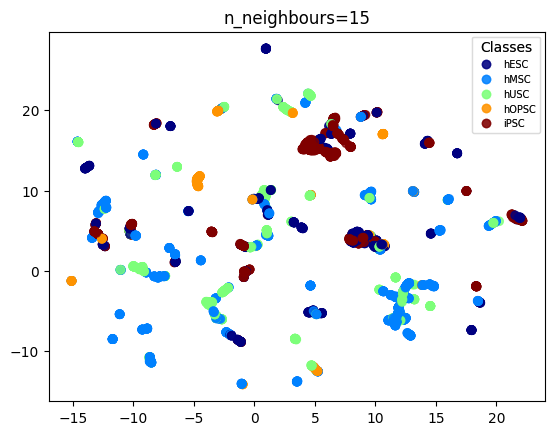

In [512]:
# for plotting one UMAP

n_neighbours = 15
reducer = umap.UMAP(n_neighbors=n_neighbours)
embedding = reducer.fit_transform(stmfr_true_data.drop('label', axis=1))
print(embedding.shape)

fig, ax = plt.subplots()
scatter =  ax.scatter(embedding[:, 0], embedding[:,1], alpha=0.8, c=stmfr_true_data.label.map({"hESC":0, "hMSC":1, "hUSC":2, "hOPSC":3, "iPSC":4}), cmap='jet')
legend1 = ax.legend(handles=scatter.legend_elements(alpha=0.8)[0], labels=["hESC", "hMSC", "hUSC", "hOPSC", "iPSC"],
                    loc="best", title="Classes", draggable=True, fontsize=7, framealpha=0.5)
ax.add_artist(legend1)
plt.title("n_neighbours="+str(n_neighbours))
plt.show()

In [1]:
# for plotting multiple UMAPs with different values of n_neighbours
from umap import UMAP

n=[15, 30, 58, 100, 250, 500, 750, 1000]

fig = plt.figure(figsize=(12,12))

for c, i in enumerate(n):
    reducer = UMAP(n_neighbors=i)
    embedding = reducer.fit_transform(stmfr_true_data.drop('label', axis=1))
#     embedding.shape

    ax = plt.subplot(3,3,c+1)
    plt.tight_layout()
    scatter =  ax.scatter(embedding[:, 0], embedding[:,1], alpha=0.8, c=stmfr_true_data.label.map({"hESC":0, "hMSC":1, "hUSC":2, "hOPSC":3, "iPSC":4}), cmap='jet')
    legend1 = ax.legend(handles=scatter.legend_elements(alpha=0.8)[0], labels=["hESC", "hMSC", "hUSC", "hOPSC", "iPSC"],
                        loc="best", title="Classes", draggable=True, fontsize=7, framealpha=0.5)
    ax.add_artist(legend1)
    plt.title("n_neighbours="+str(i))
    fig

NameError: name 'plt' is not defined

# Getting the number of samples containing all the protein-encoding genes

In [ ]:
with open('tcga_ensembl_data.txt', 'r') as file:
    r = file.read()

tcga_genes = r.split('\n')     
tcga_genes.pop()

In [ ]:
x = []
no_samples = 0
for i in list_of_dfs_copy:
        x.append(len(set(tcga_genes).intersection(set(i.index.to_list()))))
        if len(set(tcga_genes).intersection(set(i.index.to_list())))> 18000:
            no_samples+= len(i.columns.to_list())
print(x)
print(no_samples)

In [ ]:
print(max(x), min(x))

In [ ]:
print(no_samples)

In [ ]:
len(set(tcga_genes).intersection(set(stmfr_final_data.columns.to_list())))

In [ ]:
len(set(tcga_genes).intersection(set(stmfr_new_data.columns.to_list())))

In [5]:
stmfr_final_data = pd.read_csv('stmfr_final_data.csv')
stmfr_final_data.set_index(stmfr_final_data.loc[:, '0'], inplace=True)
stmfr_final_data.drop('0', axis=1, inplace=True)
stmfr_final_data.head(10)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,label
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,2.469731,0.143379,1.970240,1.292039,1.653393,-0.486783,-0.615523,2.039354,0.907376,1.145345,...,0.296232,0.935917,1.025435,0.472968,0.932808,1.371781,1.415515,1.336470,0.472968,hESC
7350_GSM2871132,2.659888,-0.314203,2.022056,1.127299,1.571565,-0.460062,-0.606948,2.144417,0.850824,0.910521,...,0.052061,1.148550,0.947417,0.482527,0.798672,1.559360,1.427451,1.382061,0.645808,hESC
7350_GSM2871133,2.658830,0.176000,2.096801,1.439344,1.693941,-0.537507,-0.610765,2.126621,0.927504,1.647378,...,-0.412249,1.198103,1.081165,0.530678,0.690270,1.291010,1.514178,1.510011,0.510946,hESC
7350_GSM2871134,2.527364,0.397752,2.225192,1.307433,1.510441,-0.491079,-0.611052,2.167515,0.902283,1.516733,...,-0.422043,1.196128,0.972143,0.535538,0.654856,0.885662,1.545798,1.415148,0.360496,hESC
7350_GSM2871135,2.639139,0.169204,2.114471,1.269592,1.510099,-0.614018,-0.614018,2.041727,0.936629,1.211675,...,-0.361948,1.364844,1.147922,0.528245,0.685460,1.275495,1.515484,1.537874,0.649662,hESC
7350_GSM2871136,2.641219,0.514791,2.172668,1.213579,1.592452,-0.530322,-0.608437,2.166279,0.859192,1.554487,...,-0.494583,1.263997,1.110249,0.514791,0.549508,1.334830,1.469422,1.318857,0.507615,hESC
7350_GSM2871137,2.606101,0.038249,2.147836,1.295322,1.544862,-0.553580,-0.624992,1.906276,0.848687,1.259749,...,-0.328609,1.521097,0.981242,0.565151,0.866855,1.273089,1.313272,1.628675,0.722660,hESC
7350_GSM2871138,2.654113,0.140167,2.149479,1.282119,1.519654,-0.507675,-0.619730,1.969774,0.732912,0.897109,...,-0.474342,1.494226,1.082202,0.482542,0.751856,1.122394,1.494226,1.476687,0.688091,hESC
7350_GSM2871139,2.449421,0.387904,2.202583,1.276522,1.486778,-0.543581,-0.618415,2.054155,0.836265,0.650853,...,-0.445645,1.341429,1.019994,0.594606,0.545722,0.754887,1.472176,1.583035,0.819978,hESC


## Preparing PCBC data

In [60]:
# PCBC data

pcbc_data = pd.read_csv('pcbc_data.csv')
pcbc_data.head()

,Unnamed: 0,ENSG00000000003.10,ENSG00000000005.5,ENSG00000000419.8,ENSG00000000457.8,ENSG00000000460.12,ENSG00000001036.8,ENSG00000001084.6,ENSG00000001167.10,ENSG00000001460.13,...,ENSG00000269955.2,ENSG00000270011.2,ENSG00000270136.1,ENSG00000270149.1,ENSG00000270181.1,ENSG00000270672.1,ENSG00000270757.1,ENSG00000270800.1,ENSG00000271043.1,ENSG00000271303.1
0,hESC,0.630652,-1.283879,0.650944,-0.600019,0.050209,0.569726,0.623399,0.157760,-0.440416,...,0.350114,-0.389043,-1.706989,-2.382593,-0.483187,-0.874713,0.746577,0.389885,1.925878,-0.175167
1,hESC,0.607154,-1.015227,0.583312,-0.779379,0.038668,0.527311,0.593473,0.186495,-0.311033,...,0.375280,-0.182891,-1.217938,-0.891917,-0.597296,-0.798234,0.815101,0.403588,2.028722,-0.260192
2,hESC,0.719778,-0.889385,0.761875,-0.625466,0.002303,0.713167,0.488632,0.254237,-0.360575,...,0.190006,-0.616846,-1.729340,-0.591620,-0.626456,-0.459296,0.679350,0.184717,1.924799,-0.181935
3,hESC,0.664274,-0.534653,0.741068,-0.557602,0.014898,0.684725,0.512457,0.264032,-0.257078,...,0.091978,-0.514361,-3.550393,-0.950978,-0.471717,-0.348082,0.729723,0.215553,1.940077,-0.177459
4,hESC,0.681655,-0.849716,0.664594,-0.594399,-0.202540,0.647853,0.522914,0.193587,-0.106337,...,0.207960,-0.476555,-1.722915,-0.944589,-0.675577,-0.294047,0.769521,0.281355,2.272894,-0.190672


In [61]:
header = pcbc_data.columns.to_list()
header[0] = 'label'
for i in range(1, len(header)):
    header[i] = header[i].split('.')[0]

pcbc_data.columns = header
display(pcbc_data.head())
print(pcbc_data.shape)

,label,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,...,ENSG00000269955,ENSG00000270011,ENSG00000270136,ENSG00000270149,ENSG00000270181,ENSG00000270672,ENSG00000270757,ENSG00000270800,ENSG00000271043,ENSG00000271303
0,hESC,0.630652,-1.283879,0.650944,-0.600019,0.050209,0.569726,0.623399,0.157760,-0.440416,...,0.350114,-0.389043,-1.706989,-2.382593,-0.483187,-0.874713,0.746577,0.389885,1.925878,-0.175167
1,hESC,0.607154,-1.015227,0.583312,-0.779379,0.038668,0.527311,0.593473,0.186495,-0.311033,...,0.375280,-0.182891,-1.217938,-0.891917,-0.597296,-0.798234,0.815101,0.403588,2.028722,-0.260192
2,hESC,0.719778,-0.889385,0.761875,-0.625466,0.002303,0.713167,0.488632,0.254237,-0.360575,...,0.190006,-0.616846,-1.729340,-0.591620,-0.626456,-0.459296,0.679350,0.184717,1.924799,-0.181935
3,hESC,0.664274,-0.534653,0.741068,-0.557602,0.014898,0.684725,0.512457,0.264032,-0.257078,...,0.091978,-0.514361,-3.550393,-0.950978,-0.471717,-0.348082,0.729723,0.215553,1.940077,-0.177459
4,hESC,0.681655,-0.849716,0.664594,-0.594399,-0.202540,0.647853,0.522914,0.193587,-0.106337,...,0.207960,-0.476555,-1.722915,-0.944589,-0.675577,-0.294047,0.769521,0.281355,2.272894,-0.190672


(229, 13190)


In [39]:
stmfr_final_data = pd.read_csv('stmfr_final_data.csv')
index = stmfr_final_data.iloc[:, 0]
stmfr_final_data.set_index(index, inplace=True)
stmfr_final_data.drop('0', axis=1, inplace=True)
stmfr_final_data.head()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000266964,ENSG00000267080,ENSG00000267120,ENSG00000267281,ENSG00000267534,ENSG00000267629,ENSG00000267680,ENSG00000267740,ENSG00000267796,label
0,,,,,,,,,,,,,,,,,,,,,
7350_GSM2871131,2.469731,0.143379,1.970240,1.292039,1.653393,-0.486783,-0.615523,2.039354,0.907376,1.145345,...,0.296232,0.935917,1.025435,0.472968,0.932808,1.371781,1.415515,1.336470,0.472968,hESC
7350_GSM2871132,2.659888,-0.314203,2.022056,1.127299,1.571565,-0.460062,-0.606948,2.144417,0.850824,0.910521,...,0.052061,1.148550,0.947417,0.482527,0.798672,1.559360,1.427451,1.382061,0.645808,hESC
7350_GSM2871133,2.658830,0.176000,2.096801,1.439344,1.693941,-0.537507,-0.610765,2.126621,0.927504,1.647378,...,-0.412249,1.198103,1.081165,0.530678,0.690270,1.291010,1.514178,1.510011,0.510946,hESC
7350_GSM2871134,2.527364,0.397752,2.225192,1.307433,1.510441,-0.491079,-0.611052,2.167515,0.902283,1.516733,...,-0.422043,1.196128,0.972143,0.535538,0.654856,0.885662,1.545798,1.415148,0.360496,hESC
7350_GSM2871135,2.639139,0.169204,2.114471,1.269592,1.510099,-0.614018,-0.614018,2.041727,0.936629,1.211675,...,-0.361948,1.364844,1.147922,0.528245,0.685460,1.275495,1.515484,1.537874,0.649662,hESC


In [62]:
pcbc_genes = pcbc_data.columns.to_list()
print(len(set(pcbc_genes).intersection(set(stmfr_final_data.columns.to_list()))))

9230


In [63]:
pcbc_data.drop(list(set(pcbc_genes).difference(set(stmfr_final_data.columns.to_list()))), axis=1, inplace=True)
pcbc_data.shape

(229, 9230)

In [64]:
difference = list(set(stmfr_final_data.columns.to_list()).difference(set(pcbc_genes)))

In [65]:
for i in difference:
    pcbc_data[i] = 0

pcbc_data.shape

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

...

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/tmp/ipykernel_6806/1199358101.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pcbc_data[i] = 0
/

(229, 11981)

In [67]:
pcbc_data['label'].value_counts()

hESC    125
hMSC    102
iPSC      2
Name: label, dtype: int64

In [68]:
pcbc_data.to_csv('pcbc_final_data.csv')

## TCGA data

In [629]:
tcga_data = pd.read_csv('tcga_gene_zscore_data.csv')
tcga_data.head()

,Unnamed: 0,TCGA-4P-AA8J-01,TCGA-BA-4074-01,TCGA-BA-4075-01,TCGA-BA-4076-01,TCGA-BA-4077-01,TCGA-BA-4078-01,TCGA-BA-5149-01,TCGA-BA-5151-01,TCGA-BA-5152-01,...,TCGA-AG-A01Y-01,TCGA-AG-A020-01,TCGA-AG-A023-01,TCGA-AG-A025-01,TCGA-AG-A026-01,TCGA-AG-A02G-01,TCGA-AG-A02N-01,TCGA-AG-A02X-01,TCGA-AG-A032-01,TCGA-AG-A036-01
0,ENSG00000290945,-0.186276,-0.276669,-0.622214,-0.586668,-0.198409,0.021640,-0.374643,-0.623674,-0.565526,...,4.019727,0.918025,1.118908,1.827976,2.392162,1.964005,-0.327544,0.024747,1.015419,0.237977
1,ENSG00000290600,-0.068389,-0.888055,-0.744756,-0.603589,-0.831730,-0.141101,-0.715129,-0.713463,-0.972733,...,0.812092,-0.599689,-0.226215,-0.078458,0.318343,0.944299,-0.376256,-0.273096,0.218869,-0.050871
2,ENSG00000201659,-0.579233,-0.579233,-0.579233,-0.151927,-0.579233,0.138804,-0.579233,-0.579233,-0.579233,...,0.245935,0.972079,-0.579233,-0.579233,1.239706,-0.579233,-0.579233,-0.579233,0.446108,-0.579233
3,ENSG00000290708,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,...,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152
4,ENSG00000187690,-0.077528,-0.100728,-0.100728,-0.100728,-0.100728,-0.092137,-0.100728,-0.100728,-0.008249,...,-0.076046,-0.100728,-0.094988,-0.100728,-0.100728,-0.100728,-0.100728,-0.100728,-0.094594,-0.100728


In [630]:
tcga_data.shape

(19835, 11071)

In [632]:
len(set(tcga_data['Unnamed: 0']).intersection(stmfr_final_data.columns.to_list()))

11483

In [633]:
index = tcga_data['Unnamed: 0']
tcga_data.set_index(index, inplace=True)
tcga_data.drop('Unnamed: 0', axis=1, inplace=True)
tcga_data.head()

,TCGA-4P-AA8J-01,TCGA-BA-4074-01,TCGA-BA-4075-01,TCGA-BA-4076-01,TCGA-BA-4077-01,TCGA-BA-4078-01,TCGA-BA-5149-01,TCGA-BA-5151-01,TCGA-BA-5152-01,TCGA-BA-5153-01,...,TCGA-AG-A01Y-01,TCGA-AG-A020-01,TCGA-AG-A023-01,TCGA-AG-A025-01,TCGA-AG-A026-01,TCGA-AG-A02G-01,TCGA-AG-A02N-01,TCGA-AG-A02X-01,TCGA-AG-A032-01,TCGA-AG-A036-01
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000290945,-0.186276,-0.276669,-0.622214,-0.586668,-0.198409,0.021640,-0.374643,-0.623674,-0.565526,-0.347812,...,4.019727,0.918025,1.118908,1.827976,2.392162,1.964005,-0.327544,0.024747,1.015419,0.237977
ENSG00000290600,-0.068389,-0.888055,-0.744756,-0.603589,-0.831730,-0.141101,-0.715129,-0.713463,-0.972733,-0.609346,...,0.812092,-0.599689,-0.226215,-0.078458,0.318343,0.944299,-0.376256,-0.273096,0.218869,-0.050871
ENSG00000201659,-0.579233,-0.579233,-0.579233,-0.151927,-0.579233,0.138804,-0.579233,-0.579233,-0.579233,-0.579233,...,0.245935,0.972079,-0.579233,-0.579233,1.239706,-0.579233,-0.579233,-0.579233,0.446108,-0.579233
ENSG00000290708,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,...,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152
ENSG00000187690,-0.077528,-0.100728,-0.100728,-0.100728,-0.100728,-0.092137,-0.100728,-0.100728,-0.008249,-0.100728,...,-0.076046,-0.100728,-0.094988,-0.100728,-0.100728,-0.100728,-0.100728,-0.100728,-0.094594,-0.100728


In [634]:
tcga_data.fillna(0, inplace=True)
tcga_data.head()

,TCGA-4P-AA8J-01,TCGA-BA-4074-01,TCGA-BA-4075-01,TCGA-BA-4076-01,TCGA-BA-4077-01,TCGA-BA-4078-01,TCGA-BA-5149-01,TCGA-BA-5151-01,TCGA-BA-5152-01,TCGA-BA-5153-01,...,TCGA-AG-A01Y-01,TCGA-AG-A020-01,TCGA-AG-A023-01,TCGA-AG-A025-01,TCGA-AG-A026-01,TCGA-AG-A02G-01,TCGA-AG-A02N-01,TCGA-AG-A02X-01,TCGA-AG-A032-01,TCGA-AG-A036-01
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
ENSG00000290945,-0.186276,-0.276669,-0.622214,-0.586668,-0.198409,0.021640,-0.374643,-0.623674,-0.565526,-0.347812,...,4.019727,0.918025,1.118908,1.827976,2.392162,1.964005,-0.327544,0.024747,1.015419,0.237977
ENSG00000290600,-0.068389,-0.888055,-0.744756,-0.603589,-0.831730,-0.141101,-0.715129,-0.713463,-0.972733,-0.609346,...,0.812092,-0.599689,-0.226215,-0.078458,0.318343,0.944299,-0.376256,-0.273096,0.218869,-0.050871
ENSG00000201659,-0.579233,-0.579233,-0.579233,-0.151927,-0.579233,0.138804,-0.579233,-0.579233,-0.579233,-0.579233,...,0.245935,0.972079,-0.579233,-0.579233,1.239706,-0.579233,-0.579233,-0.579233,0.446108,-0.579233
ENSG00000290708,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,...,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152,-0.109152
ENSG00000187690,-0.077528,-0.100728,-0.100728,-0.100728,-0.100728,-0.092137,-0.100728,-0.100728,-0.008249,-0.100728,...,-0.076046,-0.100728,-0.094988,-0.100728,-0.100728,-0.100728,-0.100728,-0.100728,-0.094594,-0.100728


In [635]:
tcga_data.sort_index(inplace=True)
tcga_data = tcga_data.transpose()
tcga_data.head()

Unnamed: 0,126231,55872,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000291180,ENSG00000291187,ENSG00000291206,ENSG00000291207,ENSG00000291228,ENSG00000291237,ENSG00000291266,ENSG00000291280,ENSG00000291281,ENSG00000291300
TCGA-4P-AA8J-01,-0.443587,-0.393323,-0.660760,-0.0516,-0.315193,-0.943822,-0.380364,-0.200853,-0.197779,0.285794,...,-0.305476,-0.292537,-0.099895,-0.295943,-0.555993,-0.344433,-0.227202,-0.436094,0.010934,0.283626
TCGA-BA-4074-01,-0.077280,2.879981,0.734845,-0.0516,4.122519,-0.570718,1.866481,-0.293382,-0.174223,0.530486,...,-0.461725,-0.292537,-0.112546,-0.336402,-0.820481,0.835536,-0.546866,-0.436094,-0.180195,0.046050
TCGA-BA-4075-01,-0.251259,1.506721,-0.137566,-0.0516,3.951437,-0.934663,0.550249,-0.225749,-0.246877,-0.633872,...,-0.492838,-0.041216,-0.338734,0.140769,-0.352152,0.011310,-0.118285,-0.436094,1.414959,-0.200441
TCGA-BA-4076-01,-0.414005,-0.029405,-0.588152,-0.0516,0.275611,-0.589297,-0.137961,-0.329927,-0.321080,4.044168,...,-0.492838,-0.292537,-0.447692,-0.106453,-0.583818,-0.298769,-0.375046,-0.359658,-0.043160,-0.220091
TCGA-BA-4077-01,-0.610346,0.754754,-0.590541,-0.0516,-0.603677,-0.350072,0.741167,-0.025565,-0.093639,0.402375,...,-0.470115,-0.292537,-0.369978,-1.057384,-0.518238,0.719575,-0.199841,-0.436094,0.135704,-0.181216


In [636]:
tcga_data.drop(list(set(tcga_data.columns.to_list()).difference(set(stmfr_final_data.columns.to_list()))), axis=1, inplace=True)
print(tcga_data.shape)

(11070, 11483)


In [637]:
tcga_data

Unnamed: 0,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001167,ENSG00000001460,ENSG00000001461,...,ENSG00000262814,ENSG00000263002,ENSG00000264424,ENSG00000265681,ENSG00000266173,ENSG00000266964,ENSG00000267080,ENSG00000267534,ENSG00000267680,ENSG00000267796
TCGA-4P-AA8J-01,-0.660760,-0.051600,-0.315193,-0.943822,-0.380364,-0.200853,-0.197779,-0.528666,-0.423831,-0.289101,...,0.388383,-0.270048,-0.052804,-1.115175,0.169072,-0.196144,0.556496,0.391311,-0.498943,1.504546
TCGA-BA-4074-01,0.734845,-0.051600,4.122519,-0.570718,1.866481,-0.293382,-0.174223,-0.374161,0.473098,-0.779825,...,1.502247,-0.562833,-0.060230,-0.390883,-1.011777,-0.224913,-0.967386,-0.429786,-1.243142,-0.219662
TCGA-BA-4075-01,-0.137566,-0.051600,3.951437,-0.934663,0.550249,-0.225749,-0.246877,0.137983,0.155545,-0.494751,...,-0.417978,-1.046292,-0.061492,-0.842091,-1.324150,-0.327035,-1.524428,-0.634320,-1.261824,-0.156087
TCGA-BA-4076-01,-0.588152,-0.051600,0.275611,-0.589297,-0.137961,-0.329927,-0.321080,-0.158018,0.008967,-0.490037,...,-0.520534,-0.471914,-0.061492,-1.149174,-0.782324,-0.346863,-0.405294,-0.478480,-0.664333,-0.552089
TCGA-BA-4077-01,-0.590541,-0.051600,-0.603677,-0.350072,0.741167,-0.025565,-0.093639,-0.639857,0.363241,-0.244988,...,-0.885440,-1.444482,-0.061492,-1.247328,-0.787814,-0.332242,-0.669118,-0.369545,-1.071120,-0.471678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AG-A02G-01,2.634805,-0.049896,1.825512,0.044723,0.177839,-0.344699,-0.355603,0.305939,-0.739495,-0.491821,...,1.379861,-0.058190,-0.045030,0.815619,-0.928585,-0.338766,0.452958,-0.713442,0.074171,-0.566363
TCGA-AG-A02N-01,1.246995,-0.022409,0.284066,0.347911,0.430007,-0.292871,-0.344678,0.351729,-0.357089,-0.047916,...,0.460415,0.514789,-0.061492,0.970339,-0.690971,-0.346183,-1.076224,-0.718697,0.536177,-0.728771
TCGA-AG-A02X-01,-0.396372,-0.051600,0.070934,-0.268860,0.884912,-0.358641,-0.355982,-0.622272,-0.576276,-0.204814,...,0.552550,-0.531576,-0.033754,-0.452201,-1.587790,-0.348561,-0.603177,-0.829358,-0.666477,-0.320299
TCGA-AG-A032-01,0.393336,0.022616,1.916500,-0.136676,0.020369,-0.316244,-0.342202,-0.235499,-0.033046,-0.400416,...,0.774888,0.286117,-0.056898,-0.028596,-1.190876,-0.300330,1.113998,-0.437871,0.276062,0.565643


In [638]:
genes = list(set(stmfr_final_data.columns.to_list()).difference(set(tcga_data.columns.to_list())))
tcga_data[genes] = 0.0

/tmp/ipykernel_6806/2619121520.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tcga_data[genes] = 0.0
/tmp/ipykernel_6806/2619121520.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tcga_data[genes] = 0.0
/tmp/ipykernel_6806/2619121520.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tcga_d

/tmp/ipykernel_6806/2619121520.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tcga_data[genes] = 0.0
/tmp/ipykernel_6806/2619121520.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tcga_data[genes] = 0.0
/tmp/ipykernel_6806/2619121520.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  tcga_d

In [643]:
# tcga_data.drop('label', axis=1, inplace=True)
# tcga_data.head()
set(tcga_data.columns.to_list()).symmetric_difference(set(stmfr_true_data.columns.to_list()))

{'label'}

In [650]:
tcga_data.to_csv('tcga_final_data.csv')